In [4]:
import os

dataset_path = "/Volumes/Macbook OS - Data/camera-trap-species-identifier(v1.1)/data/raw-img"

for cls in os.listdir(dataset_path):
    cls_path = os.path.join(dataset_path, cls)

    if os.path.isdir(cls_path):
        print(cls, len(os.listdir(cls_path)))

gallina 3098
ragno 4821
gatto 1668
farfalla 2112
mucca 1866
cavallo 2623
cane 4863
pecora 1820
scoiattolo 1862
elefante 1446


In [6]:
import os
import random
import shutil

random.seed(42)

source = "/Volumes/Macbook OS - Data/camera-trap-species-identifier(v1.1)/data/raw-img"
destination = "/Volumes/Macbook OS - Data/camera-trap-species-identifier(v1.1)/data/processed"

rare_species = [
    "elefante",
    "farfalla",
    "scoiattolo"
]

for cls in os.listdir(source):

    class_dir = os.path.join(source, cls)

    if not os.path.isdir(class_dir):
        continue

    images = os.listdir(class_dir)

    if cls in rare_species:
        keep = min(150, len(images))
    else:
        keep = min(1000, len(images))

    selected = random.sample(images, keep)

    target_dir = os.path.join(destination, cls)
    os.makedirs(target_dir, exist_ok=True)

    for img in selected:
        shutil.copy(
            os.path.join(class_dir, img),
            os.path.join(target_dir, img)
        )

print("Done")

Done


In [7]:
for cls in os.listdir("/Volumes/Macbook OS - Data/camera-trap-species-identifier(v1.1)/data/processed"):

    path = os.path.join("/Volumes/Macbook OS - Data/camera-trap-species-identifier(v1.1)/data/processed", cls)

    print(cls, len(os.listdir(path)))

gallina 1000
ragno 1000
gatto 1000
farfalla 150
mucca 1000
cavallo 1000
cane 1000
pecora 1000
scoiattolo 150
elefante 150


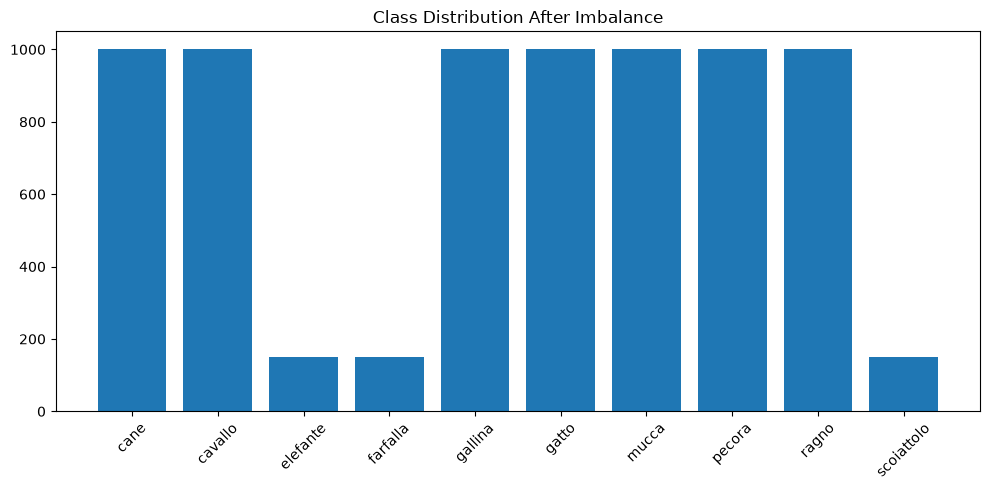

In [8]:
import os
import matplotlib.pyplot as plt

classes = []
counts = []

root = "/Volumes/Macbook OS - Data/camera-trap-species-identifier(v1.1)/data/processed"

for cls in sorted(os.listdir(root)):
    path = os.path.join(root, cls)

    if os.path.isdir(path):
        classes.append(cls)
        counts.append(len(os.listdir(path)))

plt.figure(figsize=(10,5))
plt.bar(classes, counts)

plt.xticks(rotation=45)
plt.title("Class Distribution After Imbalance")

plt.tight_layout()

plt.savefig("/Volumes/Macbook OS - Data/camera-trap-species-identifier(v1.1)/reports/class_distribution.png")

plt.show()

In [9]:
import os
import random
import shutil

random.seed(42)

RAW_DIR = "/Volumes/Macbook OS - Data/camera-trap-species-identifier(v1.1)/data/raw-img"
PROCESSED_DIR = "/Volumes/Macbook OS - Data/camera-trap-species-identifier(v1.1)/data/processed"

# -----------------------------
# FINAL TARGET DISTRIBUTION
# -----------------------------
TARGET_COUNTS = {
    "elefante": 150,
    "scoiattolo": 150,
    "farfalla": 150,

    "cane": 1000,
    "ragno": 1000,
    "cavallo": 1000,
    "gallina": 1000,
    "gatto": 1000,
    "mucca": 1000,
    "pecora": 1000
}

# -----------------------------
# CREATE IMBALANCED DATASET
# -----------------------------
def create_imbalance():
    if os.path.exists(PROCESSED_DIR):
        shutil.rmtree(PROCESSED_DIR)

    os.makedirs(PROCESSED_DIR, exist_ok=True)

    for cls, target_count in TARGET_COUNTS.items():

        src_folder = os.path.join(RAW_DIR, cls)
        dst_folder = os.path.join(PROCESSED_DIR, cls)

        os.makedirs(dst_folder, exist_ok=True)

        images = os.listdir(src_folder)

        # ensure reproducibility
        random.shuffle(images)

        selected_images = images[:target_count]

        for img in selected_images:
            src_path = os.path.join(src_folder, img)
            dst_path = os.path.join(dst_folder, img)

            shutil.copy2(src_path, dst_path)

        print(f"{cls}: {len(selected_images)} images copied")

create_imbalance()

elefante: 150 images copied
scoiattolo: 150 images copied
farfalla: 150 images copied
cane: 1000 images copied
ragno: 1000 images copied
cavallo: 1000 images copied
gallina: 1000 images copied
gatto: 1000 images copied
mucca: 1000 images copied
pecora: 1000 images copied


In [10]:
import os

PROCESSED_DIR = "/Volumes/Macbook OS - Data/camera-trap-species-identifier(v1.1)/data/processed"

for cls in sorted(os.listdir(PROCESSED_DIR)):
    path = os.path.join(PROCESSED_DIR, cls)
    print(cls, len(os.listdir(path)))

cane 1000
cavallo 1000
elefante 150
farfalla 150
gallina 1000
gatto 1000
mucca 1000
pecora 1000
ragno 1000
scoiattolo 150


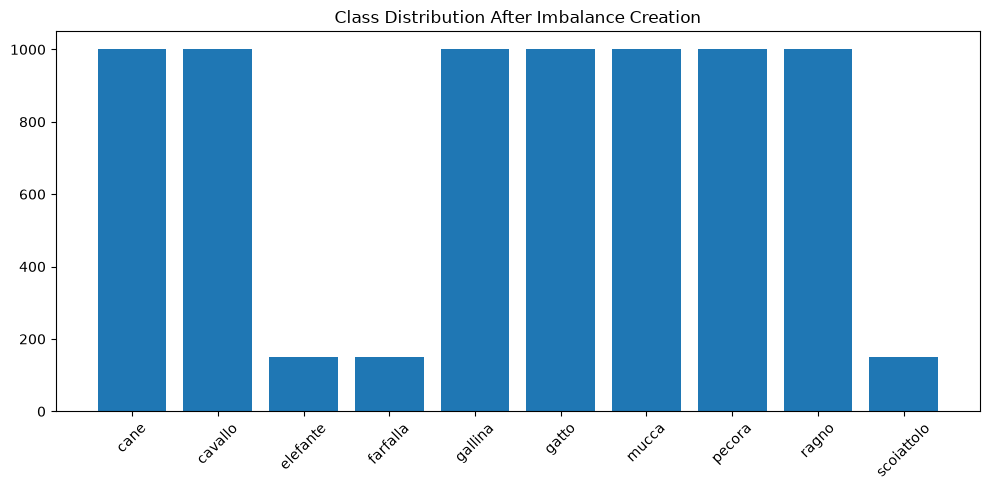

In [11]:
import matplotlib.pyplot as plt
import os

classes = []
counts = []

for cls in sorted(os.listdir(PROCESSED_DIR)):
    path = os.path.join(PROCESSED_DIR, cls)
    classes.append(cls)
    counts.append(len(os.listdir(path)))

plt.figure(figsize=(10,5))
plt.bar(classes, counts)
plt.xticks(rotation=45)
plt.title("Class Distribution After Imbalance Creation")
plt.tight_layout()

plt.savefig("/Volumes/Macbook OS - Data/camera-trap-species-identifier(v1.1)/reports/class_distribution.png")
plt.show()